# Machine Unlearning on MNIST

The goal is to deploy a toy unlearning method over MNIST, for education purposes.

# First, train an MNIST classifier

### Imports

In [1]:
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils.prune as prune

import numpy as np
import matplotlib.pyplot as plt
import copy

import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid

%matplotlib inline

# Data

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.15MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.84MB/s]


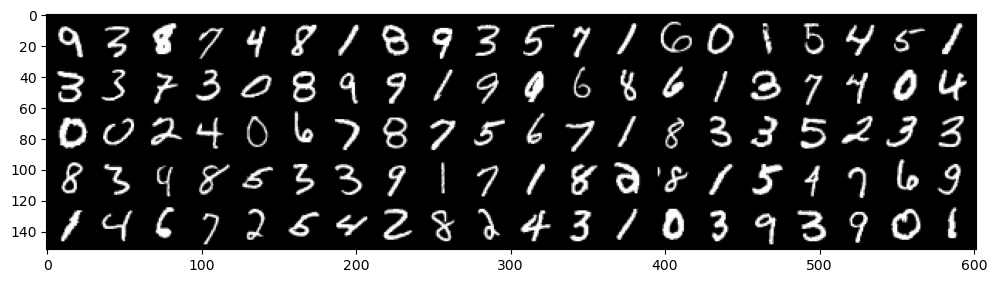

In [2]:
mnist_train = MNIST(root='data/', download=True, train=True, transform=transforms.ToTensor())
train_loader = DataLoader(mnist_train, batch_size=100, shuffle=True)

mnist_test = MNIST(root='data/', train=False, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=500)

def get_dataloaders(train_batch_size = 100, val_split=0.2):
    """Create train and validation dataloaders."""

    val_size = int(len(mnist_train) * val_split)
    train_size = len(mnist_train) - val_size

    train_dataset, val_dataset = random_split(
        mnist_train,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size = train_batch_size, shuffle = True, num_workers = 0)
    val_loader = DataLoader(val_dataset, batch_size = 500, shuffle = False, num_workers = 0)

    print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images\n")

    return train_loader, val_loader

def get_random_batch():
    
    data_iterator = iter(train_loader)
    X, y = next(data_iterator)
    
    return X, y

def check_test_accuracy(model, device):
    
    model.eval()
    num_correct = 0
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        with torch.no_grad(): # Gradients aren't needed just for test evaluation
            y_hat = model(X).argmax(-1)
        num_correct += (y_hat == y).cpu().numpy().sum()
    return num_correct / len(mnist_test)

plt.figure(figsize=(12,4));
X, y = get_random_batch()
plt.imshow(make_grid(X, nrow=20).permute((1,2,0)));

In [3]:
X, y = next(iter(train_loader))
X.shape

torch.Size([100, 1, 28, 28])

# Model

In [4]:
class ConvNet(nn.Module):
    def __init__(self):
        """
        """
        super().__init__()
        self.conv1 = nn.Sequential(

            # 28x28 -> 14x14
            nn.Conv2d(1, 8, 3, 2, 1),
            nn.ReLU(),

            # 14x14 -> 7x7
            nn.Conv2d(8, 16, 3, 2, 1),
            nn.ReLU(),

            # 7x7 -> 4x4
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            
            # 4x4 -> 2x2
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        self.flatten = nn.Flatten() # (256,)

        # This will be the first hidden layer
        self.head = nn.Sequential(
            nn.Linear(256, 64), 
            nn.ReLU(),
            nn.Linear(64, 10)
            )
        
    def forward(self, X):
        """
        The actual forward computation is defined here. This is run whenever you "call" the
        `nn.Module`, after it is instantiated.
        
        Here we will write down the computation required to run the model forward, calling
        our previously defined subnetworks
        
        """
        
        B, C, H, W = X.shape

        x = self.conv1(X) # (B x 16 x 1)
        x = self.flatten(x)
        y = self.head(x)
        return y

# Training

In [5]:
def training_regimen(model, opt, scheduler, device, num_epochs = 5):

    # load data
    train_loader, val_loader = get_dataloaders(train_batch_size = 100, val_split = 0.2)
    
    # For each epoch ...
    for k in range(num_epochs):

        # ... grab the current learning rate, 
        current_lr = opt.param_groups[0]["lr"]

        # ... train one epoch
        for i, (X, y) in enumerate(train_loader):
            
            X, y = X.to(device), y.to(device)
            
            opt.zero_grad() # zero gradients
            y_hat = model(X) # forward pass
            likelihood = dist.Categorical(logits=y_hat)
            loss = -likelihood.log_prob(y).mean()
            loss.backward()
            opt.step()

            if i % 50 == 0:
                print(f"Batch {i}: Loss = {loss.cpu().item():.4f}")
 
        # ... eval on validation set
        test_acc = check_test_accuracy(model, device)
        print(f"Epoch {k}: test accuracy = {test_acc}")

        # ... step scheduler
        scheduler.step(test_acc)

        # ... and message if learning rate changed for the next epoch
        new_lr = opt.param_groups[0]['lr']
        if new_lr < current_lr:
            print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        if new_lr < 1e-6:
            print(f"\n[EARLY STOPPING] LR {new_lr:.1e} is below threshold. Training halted.")
            break
        
    return model, opt, scheduler


# Train and Predict on Test

In [6]:
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
classifier = ConvNet().to(device)
opt = optim.Adam(classifier.parameters(), lr=1e-2)
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.2, patience=1, threshold = .01, threshold_mode = "rel")
model, opt, scheduler = training_regimen(classifier, opt, scheduler, device, num_epochs=3)

Train: 48000 images, Val: 12000 images

Batch 0: Loss = 2.3042
Batch 50: Loss = 0.5161
Batch 100: Loss = 0.2032
Batch 150: Loss = 0.2109
Batch 200: Loss = 0.1159
Batch 250: Loss = 0.1482
Batch 300: Loss = 0.1667
Batch 350: Loss = 0.1193
Batch 400: Loss = 0.0632
Batch 450: Loss = 0.0756
Epoch 0: test accuracy = 0.9652
Batch 0: Loss = 0.0660
Batch 50: Loss = 0.0803
Batch 100: Loss = 0.0506
Batch 150: Loss = 0.1612
Batch 200: Loss = 0.0427
Batch 250: Loss = 0.0933
Batch 300: Loss = 0.1564
Batch 350: Loss = 0.0204
Batch 400: Loss = 0.0877
Batch 450: Loss = 0.0835
Epoch 1: test accuracy = 0.9801
Batch 0: Loss = 0.0389
Batch 50: Loss = 0.1223
Batch 100: Loss = 0.2346
Batch 150: Loss = 0.0770
Batch 200: Loss = 0.1134
Batch 250: Loss = 0.0669
Batch 300: Loss = 0.0259
Batch 350: Loss = 0.0980
Batch 400: Loss = 0.2132
Batch 450: Loss = 0.0657
Epoch 2: test accuracy = 0.9719

[LR REDUCTION] Learning rate dropped from 1.0e-02 to 2.0e-03


In [7]:
check_test_accuracy(classifier, device = "mps")

np.float64(0.9719)